In [97]:
pip install pandas numpy yfinance matplotlib plotly seaborn xgboost scikit-learn


In [98]:
import pandas as pd
import numpy as np
import math
import datetime as dt
import yfinance as yf
import os


import matplotlib.pyplot as plt
from itertools import cycle
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score, r2_score
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance, accuracy_score
from sklearn.preprocessing import MinMaxScaler

from plotly.offline import plot, iplot, init_notebook_mode
init_notebook_mode(connected=True)


In [99]:
zomato_ticker = yf.Ticker("ZOMATO.NS")

In [100]:
if os.path.exists("zomato.csv"):
    zomato = pd.read_csv("zomato.csv", index_col=0)
else:
    zomato = zomato_ticker.history(period="max")
    zomato.to_csv("zomato.csv")

In [101]:
data=pd.read_csv('/content/zomato.csv')
data = data.rename(columns={'Date': 'date','Open':'open','High':'high','Low':'low','Close':'close',
                                'Adj Close':'adj_close','Volume':'volume'})

In [102]:
data.head()

,date,open,high,low,close,volume,Dividends,Stock Splits
0,2021-07-23 00:00:00+05:30,116.000000,138.899994,115.000000,126.000000,694895290,0.0,0.0
1,2021-07-26 00:00:00+05:30,126.349998,143.750000,125.300003,140.649994,249723854,0.0,0.0
2,2021-07-27 00:00:00+05:30,141.699997,147.800003,127.750000,132.899994,240341900,0.0,0.0
3,2021-07-28 00:00:00+05:30,131.000000,135.000000,123.550003,131.199997,159793731,0.0,0.0
4,2021-07-29 00:00:00+05:30,134.949997,144.000000,132.199997,141.550003,117973089,0.0,0.0


In [103]:
data.tail()

,date,open,high,low,close,volume,Dividends,Stock Splits
797,2024-10-15 00:00:00+05:30,283.000000,283.000000,276.100006,279.549988,23988729,0.0,0.0
798,2024-10-16 00:00:00+05:30,279.000000,279.399994,273.000000,274.250000,20872032,0.0,0.0
799,2024-10-17 00:00:00+05:30,275.000000,275.149994,268.600006,270.549988,25228600,0.0,0.0
800,2024-10-18 00:00:00+05:30,256.899994,270.299988,255.250000,257.450012,108015952,0.0,0.0
801,2024-10-21 00:00:00+05:30,258.000000,267.000000,254.500000,265.700012,88294852,0.0,0.0


In [104]:
data.shape

(802, 8)

In [105]:
data.describe()

,open,high,low,close,volume,Dividends,Stock Splits
count,802.000000,802.000000,802.000000,802.000000,8.020000e+02,802.0,802.0
mean,116.276558,118.598242,113.632070,116.024576,6.505304e+07,0.0,0.0
std,61.387890,62.509804,60.191344,61.393965,6.917901e+07,0.0,0.0
min,40.849998,44.400002,40.599998,41.650002,0.000000e+00,0.0,0.0
25%,64.199997,65.412500,63.000000,64.075003,3.085810e+07,0.0,0.0
50%,98.650002,100.500000,97.125000,98.599998,4.668316e+07,0.0,0.0
75%,142.424999,145.000000,138.624996,141.500004,7.332838e+07,0.0,0.0
max,298.000000,298.250000,290.549988,297.000000,6.948953e+08,0.0,0.0


In [106]:
data.isnull().sum()

,0
date,0
open,0
high,0
low,0
close,0
volume,0
Dividends,0
Stock Splits,0


In [107]:
data['date'] = pd.to_datetime(data.date)
data.head()

,date,open,high,low,close,volume,Dividends,Stock Splits
0,2021-07-23 00:00:00+05:30,116.000000,138.899994,115.000000,126.000000,694895290,0.0,0.0
1,2021-07-26 00:00:00+05:30,126.349998,143.750000,125.300003,140.649994,249723854,0.0,0.0
2,2021-07-27 00:00:00+05:30,141.699997,147.800003,127.750000,132.899994,240341900,0.0,0.0
3,2021-07-28 00:00:00+05:30,131.000000,135.000000,123.550003,131.199997,159793731,0.0,0.0
4,2021-07-29 00:00:00+05:30,134.949997,144.000000,132.199997,141.550003,117973089,0.0,0.0


In [108]:
print("Starting date: ",data.iloc[0][0])
print("Ending date: ", data.iloc[-1][0])
print("Duration: ", data.iloc[-1][0]-data.iloc[0][0])

Starting date:  2021-07-23 00:00:00+05:30
Ending date:  2024-10-21 00:00:00+05:30
Duration:  1186 days 00:00:00


<ipython-input-108-13b5327963b2>:1: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

<ipython-input-108-13b5327963b2>:2: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

<ipython-input-108-13b5327963b2>:3: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



Visualizing Dataset for Year 2021

In [109]:
y_2021 = data.loc[(data['date'] >= '2021-01-01')
                     & (data['date'] < '2022-01-01')]

y_2021.drop(y_2021[['Dividends','volume','Stock Splits']],axis=1)

,date,open,high,low,close
0,2021-07-23 00:00:00+05:30,116.000000,138.899994,115.000000,126.000000
1,2021-07-26 00:00:00+05:30,126.349998,143.750000,125.300003,140.649994
2,2021-07-27 00:00:00+05:30,141.699997,147.800003,127.750000,132.899994
3,2021-07-28 00:00:00+05:30,131.000000,135.000000,123.550003,131.199997
4,2021-07-29 00:00:00+05:30,134.949997,144.000000,132.199997,141.550003
...,...,...,...,...,...
106,2021-12-27 00:00:00+05:30,131.350006,133.850006,128.000000,132.750000
107,2021-12-28 00:00:00+05:30,133.699997,134.000000,131.649994,132.850006
108,2021-12-29 00:00:00+05:30,132.699997,137.699997,131.550003,137.100006
109,2021-12-30 00:00:00+05:30,137.050003,137.050003,133.300003,133.949997


In [112]:
monthvise= y_2021.groupby(y_2021['date'].dt.strftime('%B'))[['open','close']].mean()
new_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August',
             'September', 'October', 'November', 'December']
monthvise = monthvise.reindex(new_order, axis=0)
monthvise

,open,close
date,,
January,NaN,NaN
February,NaN,NaN
March,NaN,NaN
April,NaN,NaN
May,NaN,NaN
June,NaN,NaN
July,132.100000,134.299998
August,132.671428,132.614285
September,139.964284,139.445239


In [113]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=monthvise.index,
    y=monthvise['open'],
    name='Stock Open Price',
    marker_color='crimson'
))
fig.add_trace(go.Bar(
    x=monthvise.index,
    y=monthvise['close'],
    name='Stock Close Price',
    marker_color='lightsalmon'
))

fig.update_layout(barmode='group', xaxis_tickangle=-45,
                  title='Monthwise comparision between Stock open and close price')
fig.show()

In [114]:
y_2021.groupby(y_2021['date'].dt.strftime('%B'))['low'].min()
monthvise_high = y_2021.groupby(data['date'].dt.strftime('%B'))['high'].max()
monthvise_high = monthvise_high.reindex(new_order, axis=0)

monthvise_low = y_2021.groupby(y_2021['date'].dt.strftime('%B'))['low'].min()
monthvise_low = monthvise_low.reindex(new_order, axis=0)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=monthvise_high.index,
    y=monthvise_high,
    name='Stock high Price',
    marker_color='rgb(0, 153, 204)'
))
fig.add_trace(go.Bar(
    x=monthvise_low.index,
    y=monthvise_low,
    name='Stock low Price',
    marker_color='rgb(255, 128, 0)'
))

fig.update_layout(barmode='group',
                  title=' Monthwise High and Low stock price')
fig.show()

In [115]:
names = cycle(['Stock Open Price','Stock Close Price','Stock High Price','Stock Low Price'])

fig = px.line(y_2021, x=y_2021.date, y=[y_2021['open'], y_2021['close'],
                                          y_2021['high'], y_2021['low']],
             labels={'Date': 'Date','value':'Stock value'})
fig.update_layout(title_text='Stock analysis chart', font_size=15, font_color='black',legend_title_text='Stock Parameters')
fig.for_each_trace(lambda t:  t.update(name = next(names)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

Visualizing Dataset for Year 2023

In [116]:
y_2023 = data.loc[(data['date'] >= '2023-01-01')
                     & (data['date'] < '2024-01-01')]

y_2023.drop(y_2023[['volume','Dividends','Stock Splits']],axis=1)

,date,open,high,low,close
359,2023-01-02 00:00:00+05:30,60.650002,60.700001,59.799999,60.299999
360,2023-01-03 00:00:00+05:30,58.849998,59.549999,57.299999,58.950001
361,2023-01-04 00:00:00+05:30,58.400002,58.700001,56.000000,56.349998
362,2023-01-05 00:00:00+05:30,56.950001,57.099998,55.599998,56.200001
363,2023-01-06 00:00:00+05:30,56.200001,56.400002,54.950001,55.250000
...,...,...,...,...,...
599,2023-12-22 00:00:00+05:30,130.550003,131.000000,125.300003,128.500000
600,2023-12-26 00:00:00+05:30,128.500000,128.699997,124.300003,125.000000
601,2023-12-27 00:00:00+05:30,125.699997,127.599998,125.550003,127.050003
602,2023-12-28 00:00:00+05:30,124.900002,125.500000,120.599998,123.199997


In [117]:
monthvise= y_2023.groupby(y_2023['date'].dt.strftime('%B'))[['open','close']].mean()
new_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August',
             'September', 'October', 'November', 'December']
monthvise = monthvise.reindex(new_order, axis=0)
monthvise

,open,close
date,,
January,53.607143,52.878571
February,51.875000,51.925000
March,52.854762,52.700000
April,54.664706,55.291177
May,64.320455,64.431818
June,74.659525,74.607142
July,79.195238,79.233334
August,92.650000,92.497727
September,99.782501,99.639999


In [118]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=monthvise.index,
    y=monthvise['open'],
    name='Stock Open Price',
    marker_color='crimson'
))
fig.add_trace(go.Bar(
    x=monthvise.index,
    y=monthvise['close'],
    name='Stock Close Price',
    marker_color='lightsalmon'
))

fig.update_layout(barmode='group', xaxis_tickangle=-45,
                  title='Monthwise comparision between Stock open and close price')
fig.show()

In [119]:
y_2023.groupby(y_2023['date'].dt.strftime('%B'))['low'].min()
monthvise_high = y_2023.groupby(data['date'].dt.strftime('%B'))['high'].max()
monthvise_high = monthvise_high.reindex(new_order, axis=0)

monthvise_low = y_2023.groupby(y_2023['date'].dt.strftime('%B'))['low'].min()
monthvise_low = monthvise_low.reindex(new_order, axis=0)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=monthvise_high.index,
    y=monthvise_high,
    name='Stock high Price',
    marker_color='rgb(0, 153, 204)'
))
fig.add_trace(go.Bar(
    x=monthvise_low.index,
    y=monthvise_low,
    name='Stock low Price',
    marker_color='rgb(255, 128, 0)'
))

fig.update_layout(barmode='group',
                  title=' Monthwise High and Low stock price')
fig.show()

In [120]:
names = cycle(['Stock Open Price','Stock Close Price','Stock High Price','Stock Low Price'])

fig = px.line(y_2023, x=y_2023.date, y=[y_2023['open'], y_2023['close'],
                                          y_2023['high'], y_2023['low']],
             labels={'Date': 'Date','value':'Stock value'})
fig.update_layout(title_text='Stock analysis chart', font_size=15, font_color='black',legend_title_text='Stock Parameters')
fig.for_each_trace(lambda t:  t.update(name = next(names)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

Visualizing Dataset for Year 2024

In [121]:
y_2024 = data.loc[(data['date'] >= '2024-01-01')
                     & (data['date'] < '2024-12-31')]

y_2024.drop(y_2024[['Dividends','volume','Stock Splits']],axis=1)

,date,open,high,low,close
604,2024-01-01 00:00:00+05:30,124.449997,125.599998,122.849998,124.500000
605,2024-01-02 00:00:00+05:30,127.000000,129.449997,125.500000,128.699997
606,2024-01-03 00:00:00+05:30,128.800003,130.250000,127.099998,127.550003
607,2024-01-04 00:00:00+05:30,128.399994,130.899994,126.449997,129.750000
608,2024-01-05 00:00:00+05:30,130.899994,134.350006,128.949997,133.300003
...,...,...,...,...,...
797,2024-10-15 00:00:00+05:30,283.000000,283.000000,276.100006,279.549988
798,2024-10-16 00:00:00+05:30,279.000000,279.399994,273.000000,274.250000
799,2024-10-17 00:00:00+05:30,275.000000,275.149994,268.600006,270.549988
800,2024-10-18 00:00:00+05:30,256.899994,270.299988,255.250000,257.450012


In [122]:
monthvise= y_2024.groupby(y_2024['date'].dt.strftime('%B'))[['open','close']].mean()
new_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August',
             'September', 'October', 'November', 'December']
monthvise = monthvise.reindex(new_order, axis=0)
monthvise

,open,close
date,,
January,133.230951,133.488096
February,153.309522,153.547620
March,164.650001,164.816667
April,188.710000,188.590000
May,191.019047,189.911905
June,189.320526,189.113684
July,216.106364,217.481363
August,259.834285,258.214761
September,271.469045,272.016668


In [123]:
fig = go.Figure()

fig.add_trace(go.Bar(
    x=monthvise.index,
    y=monthvise['open'],
    name='Stock Open Price',
    marker_color='crimson'
))
fig.add_trace(go.Bar(
    x=monthvise.index,
    y=monthvise['close'],
    name='Stock Close Price',
    marker_color='lightsalmon'
))

fig.update_layout(barmode='group', xaxis_tickangle=-45,
                  title='Monthwise comparision between Stock open and close price')
fig.show()

In [124]:
y_2024.groupby(y_2024['date'].dt.strftime('%B'))['low'].min()
monthvise_high = y_2024.groupby(data['date'].dt.strftime('%B'))['high'].max()
monthvise_high = monthvise_high.reindex(new_order, axis=0)

monthvise_low = y_2024.groupby(y_2024['date'].dt.strftime('%B'))['low'].min()
monthvise_low = monthvise_low.reindex(new_order, axis=0)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=monthvise_high.index,
    y=monthvise_high,
    name='Stock high Price',
    marker_color='rgb(0, 153, 204)'
))
fig.add_trace(go.Bar(
    x=monthvise_low.index,
    y=monthvise_low,
    name='Stock low Price',
    marker_color='rgb(255, 128, 0)'
))

fig.update_layout(barmode='group',
                  title=' Monthwise High and Low stock price')
fig.show()

In [125]:
names = cycle(['Stock Open Price','Stock Close Price','Stock High Price','Stock Low Price'])

fig = px.line(y_2024, x=y_2024.date, y=[y_2024['open'], y_2024['close'],
                                          y_2024['high'], y_2024['low']],
             labels={'Date': 'Date','value':'Stock value'})
fig.update_layout(title_text='Stock analysis chart', font_size=15, font_color='black',legend_title_text='Stock Parameters')
fig.for_each_trace(lambda t:  t.update(name = next(names)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

Overall Analysis

In [126]:
y_overall=data
y_overall.drop(y_overall[['Dividends','Stock Splits','volume']],axis=1)

,date,open,high,low,close
0,2021-07-23 00:00:00+05:30,116.000000,138.899994,115.000000,126.000000
1,2021-07-26 00:00:00+05:30,126.349998,143.750000,125.300003,140.649994
2,2021-07-27 00:00:00+05:30,141.699997,147.800003,127.750000,132.899994
3,2021-07-28 00:00:00+05:30,131.000000,135.000000,123.550003,131.199997
4,2021-07-29 00:00:00+05:30,134.949997,144.000000,132.199997,141.550003
...,...,...,...,...,...
797,2024-10-15 00:00:00+05:30,283.000000,283.000000,276.100006,279.549988
798,2024-10-16 00:00:00+05:30,279.000000,279.399994,273.000000,274.250000
799,2024-10-17 00:00:00+05:30,275.000000,275.149994,268.600006,270.549988
800,2024-10-18 00:00:00+05:30,256.899994,270.299988,255.250000,257.450012


In [127]:
monthvise= y_overall.groupby(y_overall['date'].dt.strftime('%B'))[['open','close']].mean()
new_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August',
             'September', 'October', 'November', 'December']
monthvise = monthvise.reindex(new_order, axis=0)

In [128]:
names = cycle(['Stock Open Price','Stock Close Price','Stock High Price','Stock Low Price'])

fig = px.line(y_overall, x=y_overall.date, y=[y_overall['open'], y_overall['close'],
                                          y_overall['high'], y_overall['low']],
             labels={'Date': 'Date','value':'Stock value'})
fig.update_layout(title_text='Stock analysis chart', font_size=15, font_color='black',legend_title_text='Stock Parameters')
fig.for_each_trace(lambda t:  t.update(name = next(names)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

In [129]:
closedf = data[['date','close']]
print("Shape of close dataframe:", closedf.shape)

Shape of close dataframe: (802, 2)


In [130]:
closedf = closedf[closedf['date'] > '2023-06-01']
close_stock = closedf.copy()
print("Total data for prediction: ",closedf.shape[0])

Total data for prediction:  341


In [131]:
del closedf['date']
scaler=MinMaxScaler(feature_range=(0,1))
closedf=scaler.fit_transform(np.array(closedf).reshape(-1,1))
print(closedf.shape)

(341, 1)


In [132]:
training_size=int(len(closedf)*0.70)
test_size=len(closedf)-training_size
train_data,test_data=closedf[0:training_size,:],closedf[training_size:len(closedf),:1]
print("train_data: ", train_data.shape)
print("test_data: ", test_data.shape)

train_data:  (238, 1)
test_data:  (103, 1)


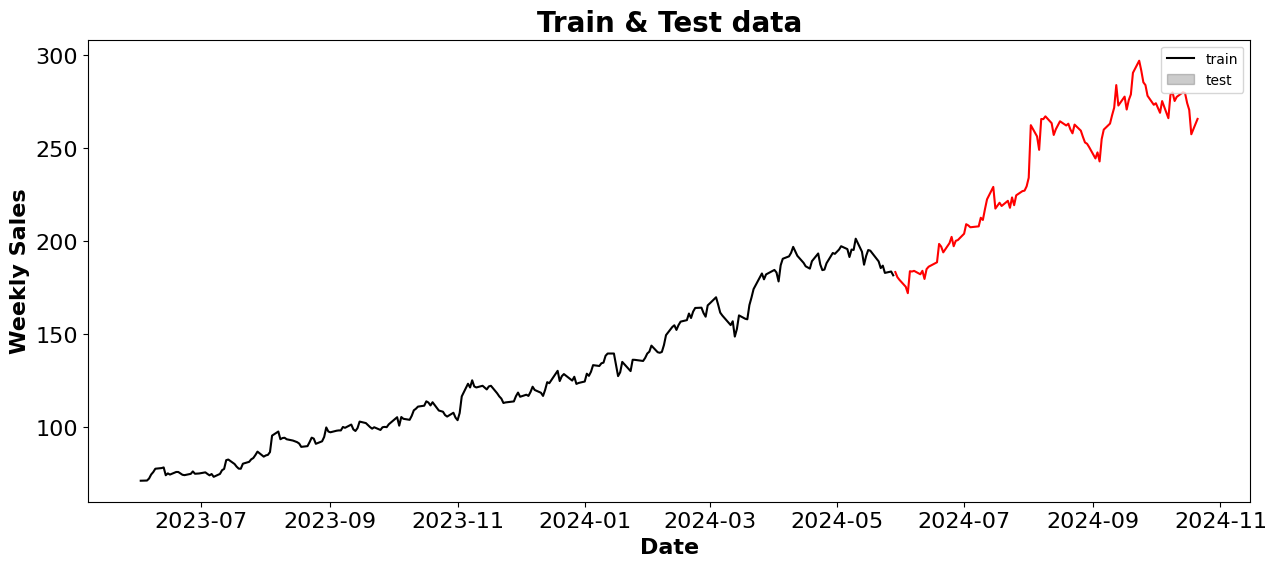

In [133]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(x = close_stock['date'][:241], y = close_stock['close'][:241], color = 'black')
sns.lineplot(x = close_stock['date'][241:], y = close_stock['close'][241:], color = 'red')

# Formatting
ax.set_title('Train & Test data', fontsize = 20, loc='center', fontdict=dict(weight='bold'))
ax.set_xlabel('Date', fontsize = 16, fontdict=dict(weight='bold'))
ax.set_ylabel('Weekly Sales', fontsize = 16, fontdict=dict(weight='bold'))
plt.tick_params(axis='y', which='major', labelsize=16)
plt.tick_params(axis='x', which='major', labelsize=16)
plt.legend(loc='upper right' ,labels = ('train', 'test'))
plt.show()

Prepare train data for time series analysis

In [134]:
 #convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-time_step-1):
        a = dataset[i:(i+time_step), 0]
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

In [135]:
time_step = 21
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

print("X_train: ", X_train.shape)
print("y_train: ", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test", y_test.shape)

X_train:  (216, 21)
y_train:  (216,)
X_test:  (81, 21)
y_test (81,)


 Import XGBRegressor module and Fit X_train and y_train for training model

In [136]:
# Biulding Model

my_model = XGBRegressor(n_estimators=1000)
my_model.fit(X_train, y_train, verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [137]:
predictions = my_model.predict(X_test)
print("Mean Absolute Error - MAE : " + str(mean_absolute_error(y_test, predictions)))
print("Root Mean squared Error - RMSE : " + str(math.sqrt(mean_squared_error(y_test, predictions))))

Mean Absolute Error - MAE : 0.2467754943128339
Root Mean squared Error - RMSE : 0.2705823709759851


In [138]:
train_predict=my_model.predict(X_train)
test_predict=my_model.predict(X_test)

train_predict = train_predict.reshape(-1,1)
test_predict = test_predict.reshape(-1,1)

print("Train data prediction:", train_predict.shape)
print("Test data prediction:", test_predict.shape)

Train data prediction: (216, 1)
Test data prediction: (81, 1)


In [139]:
# Transform back to original form

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
original_ytrain = scaler.inverse_transform(y_train.reshape(-1,1))
original_ytest = scaler.inverse_transform(y_test.reshape(-1,1))

In [140]:
 #shift train predictions for plotting

look_back=time_step
trainPredictPlot = np.empty_like(closedf)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
print("Train predicted data: ", trainPredictPlot.shape)

# shift test predictions for plotting
testPredictPlot = np.empty_like(closedf)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(closedf)-1, :] = test_predict
print("Test predicted data: ", testPredictPlot.shape)

names = cycle(['Original close price','Train predicted close price','Test predicted close price'])

plotdf = pd.DataFrame({'date': close_stock['date'],
                       'original_close': close_stock['close'],
                      'train_predicted_close': trainPredictPlot.reshape(1,-1)[0].tolist(),
                      'test_predicted_close': testPredictPlot.reshape(1,-1)[0].tolist()})

fig = px.line(plotdf,x=plotdf['date'], y=[plotdf['original_close'],plotdf['train_predicted_close'],
                                          plotdf['test_predicted_close']],
              labels={'value':'Close price','date': 'Date'})
fig.update_layout(title_text='Comparision between original close price vs predicted close price',
                  plot_bgcolor='white', font_size=15, font_color='black',legend_title_text='Close Price')
fig.for_each_trace(lambda t:  t.update(name = next(names)))

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

Train predicted data:  (341, 1)
Test predicted data:  (341, 1)


In [141]:
x_input=test_data[len(test_data)-time_step:].reshape(1,-1)
temp_input=list(x_input)
temp_input=temp_input[0].tolist()

from numpy import array

lst_output=[]
n_steps=time_step
i=0
pred_days = 10
while(i<pred_days):

    if(len(temp_input)>time_step):

        x_input=np.array(temp_input[1:])
        #print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)

        yhat = my_model.predict(x_input)
        #print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat.tolist())
        temp_input=temp_input[1:]

        lst_output.extend(yhat.tolist())
        i=i+1

    else:
        yhat = my_model.predict(x_input)

        temp_input.extend(yhat.tolist())
        lst_output.extend(yhat.tolist())

        i=i+1

print("Output of predicted next days: ", len(lst_output))

Output of predicted next days:  10


In [142]:
last_days=np.arange(1,time_step+1)
day_pred=np.arange(time_step+1,time_step+pred_days+1)
print(last_days)
print(day_pred)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
[22 23 24 25 26 27 28 29 30 31]


In [143]:
temp_mat = np.empty((len(last_days)+pred_days+1,1))
temp_mat[:] = np.nan
temp_mat = temp_mat.reshape(1,-1).tolist()[0]

last_original_days_value = temp_mat
next_predicted_days_value = temp_mat

last_original_days_value[0:time_step+1] = scaler.inverse_transform(closedf[len(closedf)-time_step:]).reshape(1,-1).tolist()[0]
next_predicted_days_value[time_step+1:] = scaler.inverse_transform(np.array(lst_output).reshape(-1,1)).reshape(1,-1).tolist()[0]

new_pred_plot = pd.DataFrame({
    'last_original_days_value':last_original_days_value,
    'next_predicted_days_value':next_predicted_days_value
})

names = cycle(['Last 15 days close price','Predicted next 10 days close price'])

fig = px.line(new_pred_plot,x=new_pred_plot.index, y=[new_pred_plot['last_original_days_value'],
                                                      new_pred_plot['next_predicted_days_value']],
              labels={'value': 'Close price','index': 'Timestamp'})
fig.update_layout(title_text='Compare last 15 days vs next 10 days',
                  plot_bgcolor='white', font_size=15, font_color='black',legend_title_text='Close Price')
fig.for_each_trace(lambda t:  t.update(name = next(names)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

In [144]:
my_model=closedf.tolist()
my_model.extend((np.array(lst_output).reshape(-1,1)).tolist())
my_model=scaler.inverse_transform(my_model).reshape(1,-1).tolist()[0]

names = cycle(['Close Price'])

fig = px.line(my_model,labels={'value': 'Close price','index': 'Timestamp'})
fig.update_layout(title_text='Plotting whole closing price with prediction',
                  plot_bgcolor='white', font_size=15, font_color='black',legend_title_text='Stock')
fig.for_each_trace(lambda t:  t.update(name = next(names)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()